# 导入库

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import lightgbm as lgb

# 模型相关库
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# 数据处理与评估库
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# 配置设置
warnings.filterwarnings('ignore')  # 忽略警告
plt.rcParams["font.family"] = ["SimHei"]  # 支持中文显示
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# EDA(数据探索性分析)

In [191]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submit = pd.read_csv('sample_submission.csv')

In [192]:
display(train_df)
train_df.info()
train_df.describe()

,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,Rent,402192.0,< 1 year,0.0,3.0,8.5,107866.0,0.0,NaN,0.0,other,Short Term,129360.0,73492.0,1900.0,697.0,0
7496,Home Mortgage,1533984.0,1 year,0.0,10.0,26.5,686312.0,0.0,43.0,0.0,debt consolidation,Long Term,444048.0,456399.0,12783.0,7410.0,1
7497,Rent,1878910.0,6 years,0.0,12.0,32.1,1778920.0,0.0,NaN,0.0,buy a car,Short Term,99999999.0,477812.0,12479.0,748.0,0
7498,Home Mortgage,NaN,NaN,0.0,21.0,26.5,1141250.0,0.0,NaN,0.0,debt consolidation,Short Term,615274.0,476064.0,37118.0,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                7500 non-null   object 
 1   Annual Income                 5943 non-null   float64
 2   Years in current job          7129 non-null   object 
 3   Tax Liens                     7500 non-null   float64
 4   Number of Open Accounts       7500 non-null   float64
 5   Years of Credit History       7500 non-null   float64
 6   Maximum Open Credit           7500 non-null   float64
 7   Number of Credit Problems     7500 non-null   float64
 8   Months since last delinquent  3419 non-null   float64
 9   Bankruptcies                  7486 non-null   float64
 10  Purpose                       7500 non-null   object 
 11  Term                          7500 non-null   object 
 12  Current Loan Amount           7500 non-null   float64
 13  Cur

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
count,5.943000e+03,7500.000000,7500.000000,7500.000000,7.500000e+03,7500.000000,3419.000000,7486.000000,7.500000e+03,7.500000e+03,7500.000000,5943.000000,7500.000000
mean,1.366392e+06,0.030133,11.130933,18.317467,9.451537e+05,0.170000,34.692600,0.117152,1.187318e+07,2.898332e+05,18314.454133,1151.087498,0.281733
std,8.453392e+05,0.271604,4.908924,7.041946,1.602622e+07,0.498598,21.688806,0.347192,3.192612e+07,3.178714e+05,11926.764673,1604.451418,0.449874
min,1.645970e+05,0.000000,2.000000,4.000000,0.000000e+00,0.000000,0.000000,0.000000,1.124200e+04,0.000000e+00,0.000000,585.000000,0.000000
25%,8.443410e+05,0.000000,8.000000,13.500000,2.792295e+05,0.000000,16.000000,0.000000,1.801690e+05,1.142565e+05,10067.500000,711.000000,0.000000
50%,1.168386e+06,0.000000,10.000000,17.000000,4.781590e+05,0.000000,32.000000,0.000000,3.095730e+05,2.093230e+05,16076.500000,731.000000,0.000000
75%,1.640137e+06,0.000000,14.000000,21.800000,7.935015e+05,0.000000,50.000000,0.000000,5.198820e+05,3.604062e+05,23818.000000,743.000000,1.000000
max,1.014934e+07,7.000000,43.000000,57.700000,1.304726e+09,7.000000,118.000000,4.000000,1.000000e+08,6.506797e+06,136679.000000,7510.000000,1.000000


In [193]:
display(test_df)
test_df.info()
test_df.describe()

,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score
0,Rent,NaN,4 years,0.0,9.0,12.5,220968.0,0.0,70.0,0.0,debt consolidation,Short Term,162470.0,105906.0,6813.0,NaN
1,Rent,231838.0,1 year,0.0,6.0,32.7,55946.0,0.0,8.0,0.0,educational expenses,Short Term,78298.0,46037.0,2318.0,699.0
2,Home Mortgage,1152540.0,3 years,0.0,10.0,13.7,204600.0,0.0,NaN,0.0,debt consolidation,Short Term,200178.0,146490.0,18729.0,7260.0
3,Home Mortgage,1220313.0,10+ years,0.0,16.0,17.0,456302.0,0.0,70.0,0.0,debt consolidation,Short Term,217382.0,213199.0,27559.0,739.0
4,Home Mortgage,2340952.0,6 years,0.0,11.0,23.6,1207272.0,0.0,NaN,0.0,debt consolidation,Long Term,777634.0,425391.0,42605.0,706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,Home Mortgage,1020053.0,10+ years,0.0,14.0,29.1,559152.0,1.0,68.0,1.0,debt consolidation,Short Term,99999999.0,162735.0,15046.0,745.0
2496,Home Mortgage,NaN,2 years,0.0,15.0,17.0,1737780.0,0.0,77.0,0.0,debt consolidation,Short Term,468512.0,1439269.0,32996.0,NaN
2497,Home Mortgage,1171806.0,2 years,0.0,48.0,12.8,1706430.0,0.0,NaN,0.0,debt consolidation,Short Term,430496.0,676438.0,36912.0,695.0
2498,Rent,723520.0,10+ years,0.0,14.0,28.8,945780.0,0.0,NaN,0.0,debt consolidation,Short Term,257774.0,391248.0,13506.0,744.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                2500 non-null   object 
 1   Annual Income                 1987 non-null   float64
 2   Years in current job          2414 non-null   object 
 3   Tax Liens                     2500 non-null   float64
 4   Number of Open Accounts       2500 non-null   float64
 5   Years of Credit History       2500 non-null   float64
 6   Maximum Open Credit           2500 non-null   float64
 7   Number of Credit Problems     2500 non-null   float64
 8   Months since last delinquent  1142 non-null   float64
 9   Bankruptcies                  2497 non-null   float64
 10  Purpose                       2500 non-null   object 
 11  Term                          2500 non-null   object 
 12  Current Loan Amount           2500 non-null   float64
 13  Cur

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score
count,1.987000e+03,2500.000000,2500.000000,2500.000000,2.500000e+03,2500.000000,1142.000000,2497.000000,2.500000e+03,2.500000e+03,2500.000000,1987.000000
mean,1.366922e+06,0.035200,11.184400,18.325920,7.105704e+05,0.162000,34.181261,0.106928,1.215572e+07,2.963966e+05,18271.340000,1234.516860
std,9.171252e+05,0.386291,4.852774,7.254659,1.511983e+06,0.559894,22.024277,0.357189,3.226097e+07,3.783020e+05,11543.881469,1740.219442
min,1.065330e+05,0.000000,1.000000,3.900000,0.000000e+00,0.000000,0.000000,0.000000,1.542200e+04,0.000000e+00,93.000000,585.000000
25%,8.523115e+05,0.000000,8.000000,13.400000,2.785860e+05,0.000000,16.000000,0.000000,1.871265e+05,1.101145e+05,10024.750000,710.000000
50%,1.178475e+06,0.000000,10.000000,17.000000,4.786760e+05,0.000000,30.000000,0.000000,3.223660e+05,2.073850e+05,16642.500000,731.000000
75%,1.629734e+06,0.000000,14.000000,22.100000,8.025985e+05,0.000000,50.000000,0.000000,5.225825e+05,3.663485e+05,24146.000000,743.000000
max,1.497561e+07,15.000000,48.000000,53.400000,5.448439e+07,15.000000,82.000000,5.000000,1.000000e+08,6.030087e+06,93555.000000,7480.000000


# 数据预处理

In [194]:
def preprocess_features(train_df, test_df, target_col='Credit Default'):
    # 创建数据的副本，避免修改原始DataFrame
    train_df_processed = train_df.copy()
    test_df_processed = test_df.copy()

    # 2. 序数编码 (Ordinal Encoding)
    years_in_job_mapping = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
        '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
        '10+ years': 10
    }
    train_df_processed['Years in current job'] = train_df_processed['Years in current job'].replace(years_in_job_mapping)
    test_df_processed['Years in current job'] = test_df_processed['Years in current job'].replace(years_in_job_mapping)

    # 3. 标签编码 (Label Encoding)
    term_mapping = {'Long Term': 1, 'Short Term': 2}
    train_df_processed['Term'] = train_df_processed['Term'].map(term_mapping).astype(int)
    test_df_processed['Term'] = test_df_processed['Term'].map(term_mapping).astype(int)
    
    return train_df_processed, test_df_processed

In [195]:
train_df, test_df = preprocess_features(train_df, test_df, target_col='Credit Default')

In [196]:
Monthly_Debt_max = train_df['Monthly Debt'].max()


def Monthly_Debt_cat(X):
    bins = [0, 10067.50, 16076.50, 23818.00, Monthly_Debt_max]
    X['Monthly_Debt_cat'] = pd.cut(X['Monthly Debt'], bins=bins, labels=False)

    X['Monthly_Debt_cat'].fillna(-1, inplace=True)
    return X
train_df = Monthly_Debt_cat(train_df)
test_df = Monthly_Debt_cat(test_df)

In [197]:
def impute_missing_values(train_df, test_df):
    annual_income_median = train_df['Annual Income'].median()
    train_df.loc[train_df['Annual Income'].isna(), 'Annual Income'] = annual_income_median
    test_df.loc[test_df['Annual Income'].isna(), 'Annual Income'] = annual_income_median
    
    months_delinquent_median = train_df['Months since last delinquent'].median()
    train_df.loc[train_df['Months since last delinquent'].isna(), 'Months since last delinquent'] = months_delinquent_median
    test_df.loc[test_df['Months since last delinquent'].isna(), 'Months since last delinquent'] = months_delinquent_median
    
    bankruptcies_median = train_df['Bankruptcies'].median()
    train_df.loc[train_df['Bankruptcies'].isna(), 'Bankruptcies'] = bankruptcies_median
    test_df.loc[test_df['Bankruptcies'].isna(), 'Bankruptcies'] = bankruptcies_median
    
    years_in_job_mode = train_df['Years in current job'].mode()[0]
    train_df.loc[train_df['Years in current job'].isna(), 'Years in current job'] = years_in_job_mode
    test_df.loc[test_df['Years in current job'].isna(), 'Years in current job'] = years_in_job_mode
    
    return train_df, test_df

In [198]:
train_df, test_df = impute_missing_values(train_df, test_df)

In [199]:
train_df.loc[train_df['Maximum Open Credit'] > 99999999.0, 'Maximum Open Credit'] = train_df['Maximum Open Credit'].median()
train_df.loc[train_df['Current Loan Amount'] == 99999999.0, 'Current Loan Amount'] = train_df['Current Loan Amount'].median()
test_df.loc[test_df['Maximum Open Credit'] > 99999999.0, 'Maximum Open Credit'] = train_df['Maximum Open Credit'].median()
test_df.loc[test_df['Current Loan Amount'] == 99999999.0, 'Current Loan Amount'] = train_df['Current Loan Amount'].median()

In [200]:
# 信用评分，大于1000的数值视为异常值，用训练集的均值进行替换
def preprocess_outlier_and_missing(train_df, test_df, col, threshold):
    # 计算训练集的均值（仅基于训练集的非异常值和非缺失值，更合理）
    # 先筛选训练集中的正常数据（≤threshold且非NaN），再求均值
    train_valid_data = train_df.loc[(train_df[col] <= threshold) & (~train_df[col].isna()), col]
    train_mean = train_valid_data.mean()  # 基于正常数据计算均值
    
    # 处理训练集：异常值和缺失值均替换为训练集均值
    train_df.loc[train_df[col] > threshold, col] = train_mean  # 异常值替换
    train_df[col].fillna(train_mean, inplace=True)  # 缺失值替换
    
    # 处理测试集：同样用训练集均值替换异常值和缺失值（关键：保持与训练集一致）
    test_df.loc[test_df[col] > threshold, col] = train_mean  # 异常值替换
    test_df[col].fillna(train_mean, inplace=True)  # 缺失值替换
    
    return train_df, test_df

feature_name = 'Credit Score'
train_df, test_df = preprocess_outlier_and_missing(train_df, test_df, feature_name, threshold=1000)

train_df[feature_name].isna().sum()

0

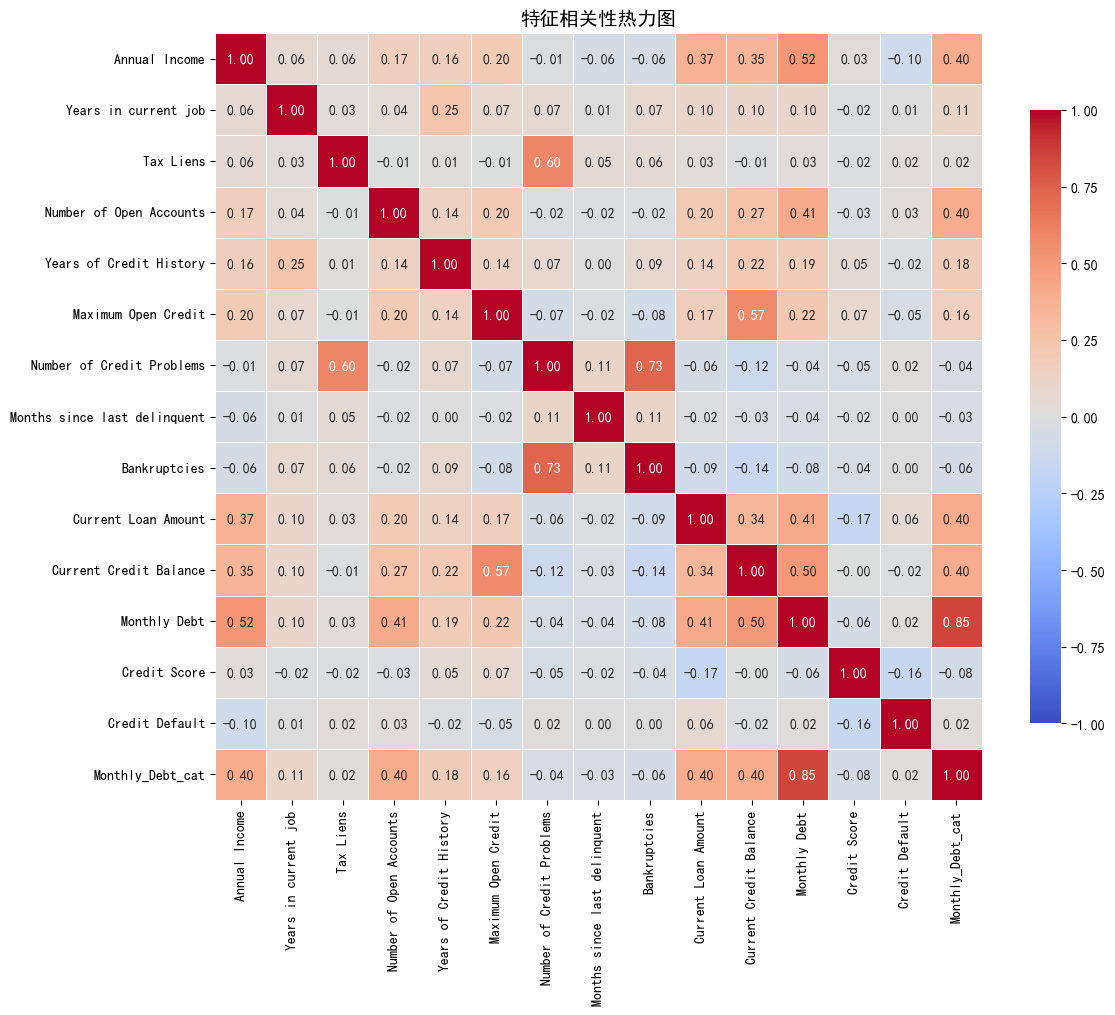

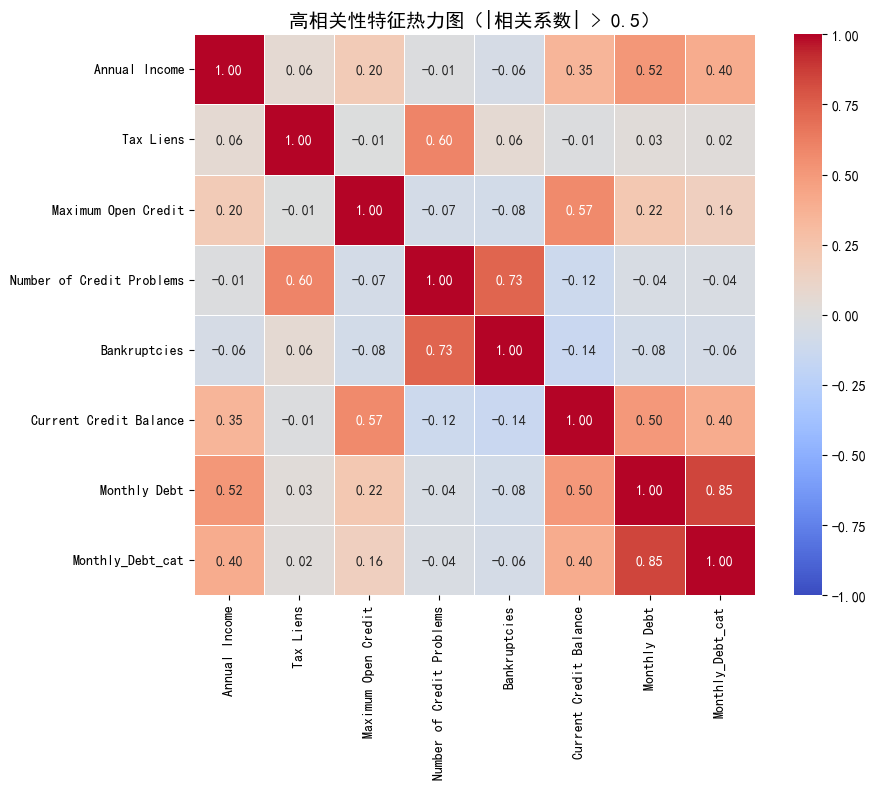

In [ ]:
# ----------------------
# 1. 数据准备（选择数值型特征计算相关性）
# ----------------------
num_features = train_df.select_dtypes(include=['int64', 'float64']).columns
if 'target' in num_features:
    num_features = num_features.drop('target')

# 计算特征间的皮尔逊相关系数
corr_matrix = train_df[num_features].corr(method='pearson')

# ----------------------
# 2. 绘制热力图
# ----------------------
plt.figure(figsize=(12, 10))  # 图表大小，特征多可增大

# 绘制热力图
sns.heatmap(
    corr_matrix,
    annot=True,  # 显示相关系数数值
    fmt=".2f",   # 数值保留2位小数
    cmap="coolwarm",  # 颜色主题（红-蓝表示正负相关）
    vmin=-1, vmax=1,  # 颜色范围（相关系数范围-1到1）
    square=True,  # 单元格为正方形
    linewidths=0.5,  # 网格线宽度
    cbar_kws={"shrink": 0.8}  # 颜色条缩放比例
)

plt.title("特征相关性热力图", fontsize=14)
plt.tight_layout()  # 调整布局
plt.show()

# ----------------------
# 3. 绘制高相关性特征子图
# ----------------------
# 筛选出相关系数绝对值大于0.5的特征对（可调整阈值）
threshold = 0.5
high_corr = corr_matrix[(abs(corr_matrix) > threshold) & (corr_matrix != 1.0)]

# 提取有高相关性的特征
high_corr_features = high_corr.stack().index.get_level_values(0).unique()

if len(high_corr_features) > 1:
    # 绘制高相关性特征的子热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix.loc[high_corr_features, high_corr_features],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5
    )
    plt.title(f"高相关性特征热力图（|相关系数| > {threshold}）", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"没有找到相关系数绝对值大于{threshold}的特征对")

In [201]:
X = train_df.drop(columns=['Home Ownership','Purpose','Credit Default'])
y = train_df['Credit Default']
X_test = test_df.drop(columns=['Home Ownership','Purpose'])

# 划分数据集

In [202]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                      test_size=0.33, 
                                                      shuffle=True, 
                                                      random_state=42, 
                                                      stratify=y)
display(y_train.value_counts(normalize=True), y_valid.value_counts(normalize=True))

Credit Default
0    0.718209
1    0.281791
Name: proportion, dtype: float64

Credit Default
0    0.718384
1    0.281616
Name: proportion, dtype: float64

In [203]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5025 entries, 1454 to 5888
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Annual Income                 5025 non-null   float64
 1   Years in current job          5025 non-null   float64
 2   Tax Liens                     5025 non-null   float64
 3   Number of Open Accounts       5025 non-null   float64
 4   Years of Credit History       5025 non-null   float64
 5   Maximum Open Credit           5025 non-null   float64
 6   Number of Credit Problems     5025 non-null   float64
 7   Months since last delinquent  5025 non-null   float64
 8   Bankruptcies                  5025 non-null   float64
 9   Term                          5025 non-null   int32  
 10  Current Loan Amount           5025 non-null   float64
 11  Current Credit Balance        5025 non-null   float64
 12  Monthly Debt                  5025 non-null   float64
 13  Credi

# 模型构建以及训练

## 线性模型

In [ ]:
# 模型定义与训练
model_lr = LogisticRegression(
    random_state=21,
    max_iter=1000,
    class_weight={0:1, 1:2.55}  # 类别权重
)
model_lr.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_lr = model_lr.predict(X_valid)
y_valid_proba_lr = model_lr.predict_proba(X_valid)[:, 1]
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_lr):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_lr):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_lr):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_lr):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_lr):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_lr)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告（详细类别指标）
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_lr))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.5838
精确率 (Precision): 0.3515
召回率 (Recall): 0.5653
F1分数 (F1-Score): 0.4334
AUC: 0.6181

===== 混淆矩阵 =====
真负例 (TN): 1051, 假正例 (FP): 727
假负例 (FN): 303, 真正例 (TP): 394

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.78      0.59      0.67      1778
           1       0.35      0.57      0.43       697

    accuracy                           0.58      2475
   macro avg       0.56      0.58      0.55      2475
weighted avg       0.66      0.58      0.60      2475



## 支持向量机

In [ ]:
# 模型定义与训练
model_linearsvc = LinearSVC(
    random_state=21,
    class_weight={0:1, 1:2.55},
    max_iter=1000
)
model_linearsvc.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_linearsvc = model_linearsvc.predict(X_valid)
y_valid_decision_linearsvc = model_linearsvc.decision_function(X_valid)  
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_linearsvc):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_linearsvc):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_linearsvc):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_linearsvc):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_decision_linearsvc):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_linearsvc)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_linearsvc))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.5721
精确率 (Precision): 0.3432
召回率 (Recall): 0.5681
F1分数 (F1-Score): 0.4279
AUC: 0.6103

===== 混淆矩阵 =====
真负例 (TN): 1020, 假正例 (FP): 758
假负例 (FN): 301, 真正例 (TP): 396

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.77      0.57      0.66      1778
           1       0.34      0.57      0.43       697

    accuracy                           0.57      2475
   macro avg       0.56      0.57      0.54      2475
weighted avg       0.65      0.57      0.59      2475



In [ ]:

# 模型定义与训练
model_dt = DecisionTreeClassifier(
    random_state=21,
    max_depth=3,
    class_weight={0:1, 1:2.55}
)
model_dt.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_dt = model_dt.predict(X_valid)
y_valid_proba_dt = model_dt.predict_proba(X_valid)[:, 1]
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_dt):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_dt):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_dt):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_dt):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_dt):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_dt)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告（详细类别指标，使用决策树的预测结果）
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_dt))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.6695
精确率 (Precision): 0.4362
召回率 (Recall): 0.5940
F1分数 (F1-Score): 0.5030
AUC: 0.7013

===== 混淆矩阵 =====
真负例 (TN): 1243, 假正例 (FP): 535
假负例 (FN): 283, 真正例 (TP): 414

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      1778
           1       0.44      0.59      0.50       697

    accuracy                           0.67      2475
   macro avg       0.63      0.65      0.63      2475
weighted avg       0.71      0.67      0.68      2475



## 决策树

In [ ]:

# 模型定义与训练
model_rf = RandomForestClassifier(
    random_state=21,
    n_estimators=60,  # 树的数量
    max_depth=3,
    class_weight={0:1, 1:2.55},
    n_jobs=-1  # 并行计算（使用所有CPU核心）
)
model_rf.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_rf = model_rf.predict(X_valid)
y_valid_proba_rf = model_rf.predict_proba(X_valid)[:, 1]
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_rf):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_rf):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_rf):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_rf):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_rf)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_rf))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.6214
精确率 (Precision): 0.4029
召回率 (Recall): 0.7145
F1分数 (F1-Score): 0.5153
AUC: 0.7107

===== 混淆矩阵 =====
真负例 (TN): 1040, 假正例 (FP): 738
假负例 (FN): 199, 真正例 (TP): 498

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.84      0.58      0.69      1778
           1       0.40      0.71      0.52       697

    accuracy                           0.62      2475
   macro avg       0.62      0.65      0.60      2475
weighted avg       0.72      0.62      0.64      2475



## 梯度提升树

In [ ]:

# 模型定义与训练
model_gbdt = GradientBoostingClassifier(
    random_state=21,
    n_estimators=100,
    max_depth=3
)
model_gbdt.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_gbdt = model_gbdt.predict(X_valid)  # GBDT预测类别
y_valid_proba_gbdt = model_gbdt.predict_proba(X_valid)[:, 1]  # GBDT正类概率
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_gbdt):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_gbdt):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_gbdt):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_gbdt):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_gbdt):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_gbdt)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_gbdt))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.7798
精确率 (Precision): 0.7405
召回率 (Recall): 0.3357
F1分数 (F1-Score): 0.4620
AUC: 0.7643

===== 混淆矩阵 =====
真负例 (TN): 1696, 假正例 (FP): 82
假负例 (FN): 463, 真正例 (TP): 234

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.79      0.95      0.86      1778
           1       0.74      0.34      0.46       697

    accuracy                           0.78      2475
   macro avg       0.76      0.64      0.66      2475
weighted avg       0.77      0.78      0.75      2475



## LGBM

In [ ]:

# 模型定义与训练
model_lgbm = lgb.LGBMClassifier(
    random_state=21,
    class_weight={0:1, 1:2.55},
    n_estimators=60,
    max_depth=3,
    reg_lambda=1.9
)
model_lgbm.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_lgbm = model_lgbm.predict(X_valid)  # LightGBM预测类别
y_valid_proba_lgbm = model_lgbm.predict_proba(X_valid)[:, 1]  # LightGBM正类概率
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_lgbm):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_lgbm):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_lgbm):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_lgbm):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_lgbm):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_lgbm)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1416, number of negative: 3609
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000773 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1816
[LightGBM] [Info] Number of data points in the train set: 5025, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500125 -> initscore=0.000499
[LightGBM] [Info] Start training from score 0.000499
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

## 贝叶斯

In [ ]:

# 模型定义与训练
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_nb = model_nb.predict(X_valid)
y_valid_proba_nb = model_nb.predict_proba(X_valid)[:, 1]
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_nb):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_nb):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_nb):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_nb):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_nb):.4f}")

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_nb)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_nb))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.5366
精确率 (Precision): 0.3377
召回率 (Recall): 0.6714
F1分数 (F1-Score): 0.4494
AUC: 0.6082

===== 混淆矩阵 =====
真负例 (TN): 860, 假正例 (FP): 918
假负例 (FN): 229, 真正例 (TP): 468

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.79      0.48      0.60      1778
           1       0.34      0.67      0.45       697

    accuracy                           0.54      2475
   macro avg       0.56      0.58      0.52      2475
weighted avg       0.66      0.54      0.56      2475



## 神经网络

In [ ]:

# 模型定义与训练
model_mlp = MLPClassifier(
    random_state=21,
    hidden_layer_sizes=(32, 16),
    max_iter=10
)
model_mlp.fit(X_train, y_train)

# 预测
print("\n===== 验证集预测 =====")
y_valid_pred_mlp = model_mlp.predict(X_valid)  # MLP预测类别
y_valid_proba_mlp = model_mlp.predict_proba(X_valid)[:, 1]  # MLP正类概率
print("预测完成")

# 计算并打印所有二分类指标
print("\n===== 核心评估指标 =====")
print(f"准确率 (Accuracy): {accuracy_score(y_valid, y_valid_pred_mlp):.4f}")
print(f"精确率 (Precision): {precision_score(y_valid, y_valid_pred_mlp):.4f}")
print(f"召回率 (Recall): {recall_score(y_valid, y_valid_pred_mlp):.4f}")
print(f"F1分数 (F1-Score): {f1_score(y_valid, y_valid_pred_mlp):.4f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba_mlp):.4f}")  # 用MLP概率计算AUC

# 混淆矩阵
print("\n===== 混淆矩阵 =====")
cm = confusion_matrix(y_valid, y_valid_pred_mlp)
print(f"真负例 (TN): {cm[0][0]}, 假正例 (FP): {cm[0][1]}")
print(f"假负例 (FN): {cm[1][0]}, 真正例 (TP): {cm[1][1]}")

# 分类报告
print("\n===== 分类报告 =====")
print(classification_report(y_valid, y_valid_pred_mlp))


===== 验证集预测 =====
预测完成

===== 核心评估指标 =====
准确率 (Accuracy): 0.3535
精确率 (Precision): 0.2893
召回率 (Recall): 0.8895
F1分数 (F1-Score): 0.4366
AUC: 0.5180

===== 混淆矩阵 =====
真负例 (TN): 255, 假正例 (FP): 1523
假负例 (FN): 77, 真正例 (TP): 620

===== 分类报告 =====
              precision    recall  f1-score   support

           0       0.77      0.14      0.24      1778
           1       0.29      0.89      0.44       697

    accuracy                           0.35      2475
   macro avg       0.53      0.52      0.34      2475
weighted avg       0.63      0.35      0.30      2475



# 可视化

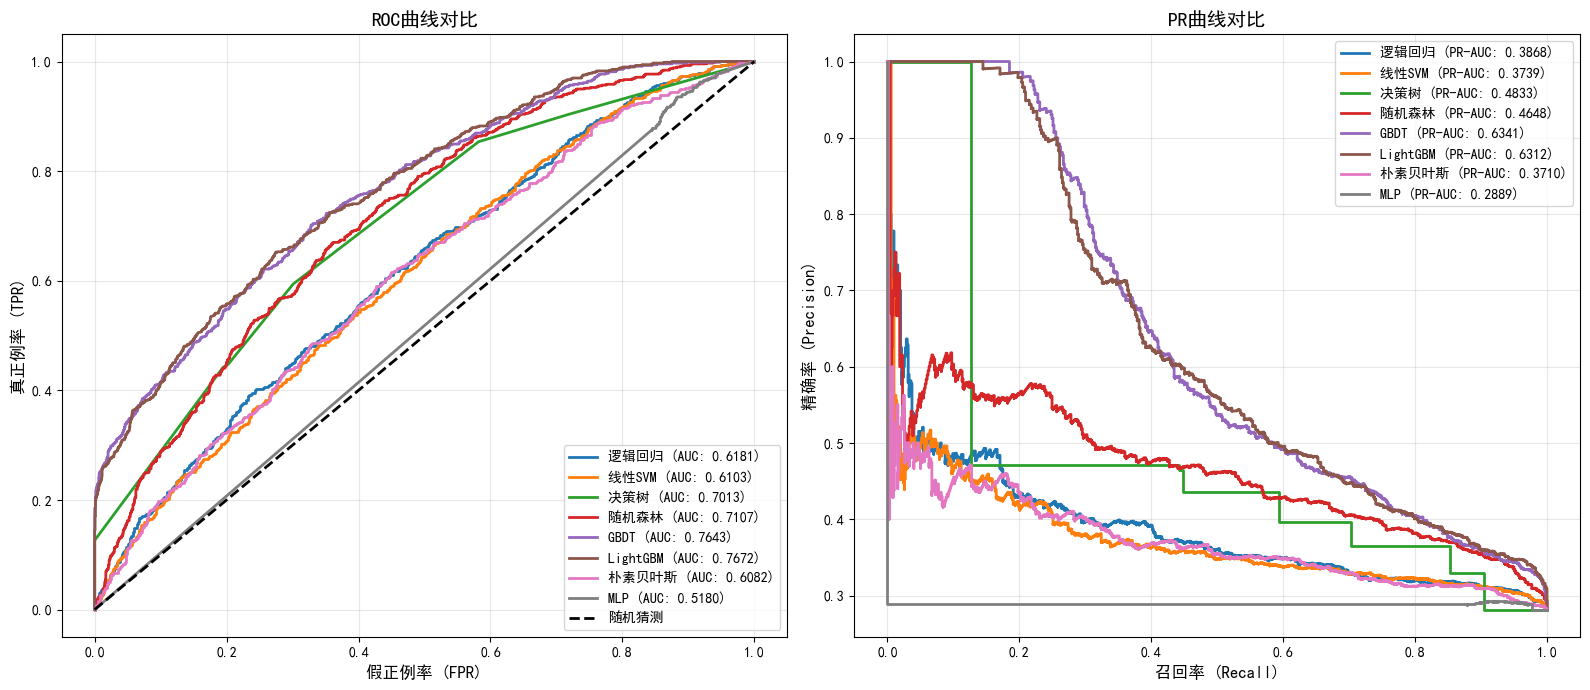

===== 各模型指标汇总 =====
       模型名称  ROC-AUC  PR-AUC     准确率     精确率     召回率    F1分数
5  LightGBM   0.7672  0.6312  0.6679  0.4440  0.7116  0.5469
4      GBDT   0.7643  0.6341  0.7798  0.7405  0.3357  0.4620
3      随机森林   0.7107  0.4648  0.6214  0.4029  0.7145  0.5153
2       决策树   0.7013  0.4833  0.6695  0.4362  0.5940  0.5030
0      逻辑回归   0.6181  0.3868  0.5838  0.3515  0.5653  0.4334
1     线性SVM   0.6103  0.3739  0.5721  0.3432  0.5681  0.4279
6     朴素贝叶斯   0.6082  0.3710  0.5366  0.3377  0.6714  0.4494
7       MLP   0.5180  0.2889  0.3535  0.2893  0.8895  0.4366


In [ ]:
# 1. 准备模型列表
models = [
    ("逻辑回归", model_lr),
    ("线性SVM", model_linearsvc),
    ("决策树", model_dt),
    ("随机森林", model_rf),
    ("GBDT", model_gbdt),
    ("LightGBM", model_lgbm),
    ("朴素贝叶斯", model_nb),
    ("MLP", model_mlp)
]

# 2. 计算所需模型的评估指标
roc_data = []
pr_data = []
metrics_summary = []

for name, model in models:
    # 获取正类概率/决策值
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_valid)[:, 1]
    else:
        y_score = model.decision_function(X_valid)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)
    
    y_pred = model.predict(X_valid)
    
    # ROC曲线
    fpr, tpr, _ = roc_curve(y_valid, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data.append((name, fpr, tpr, roc_auc))
    
    # PR曲线
    precision, recall, _ = precision_recall_curve(y_valid, y_proba)
    pr_auc = average_precision_score(y_valid, y_proba)
    pr_data.append((name, precision, recall, pr_auc))
    
    # 指标汇总
    metrics_summary.append({
        "模型名称": name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "准确率": accuracy_score(y_valid, y_pred),
        "精确率": precision_score(y_valid, y_pred),
        "召回率": recall_score(y_valid, y_pred),
        "F1分数": f1_score(y_valid, y_pred)
    })

# 3. 绘制ROC曲线和PR曲线
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 子图1：ROC曲线
ax = axes[0]
for name, fpr, tpr, roc_auc in roc_data:
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC: {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='随机猜测')
ax.set_xlabel('假正例率 (FPR)', fontsize=12)
ax.set_ylabel('真正例率 (TPR)', fontsize=12)
ax.set_title('ROC曲线对比', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# 子图2：PR曲线（图例位置改为右上角）
ax = axes[1]
for name, precision, recall, pr_auc in pr_data:
    ax.step(recall, precision, where='post', lw=2, label=f'{name} (PR-AUC: {pr_auc:.4f})')
ax.set_xlabel('召回率 (Recall)', fontsize=12)
ax.set_ylabel('精确率 (Precision)', fontsize=12)
ax.set_title('PR曲线对比', fontsize=14)
ax.legend(loc='upper right', fontsize=10)  # 关键修改：将图例放在右上角
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 输出指标汇总表
metrics_df = pd.DataFrame(metrics_summary).sort_values(by="ROC-AUC", ascending=False).round(4)
print("===== 各模型指标汇总 =====")
print(metrics_df)

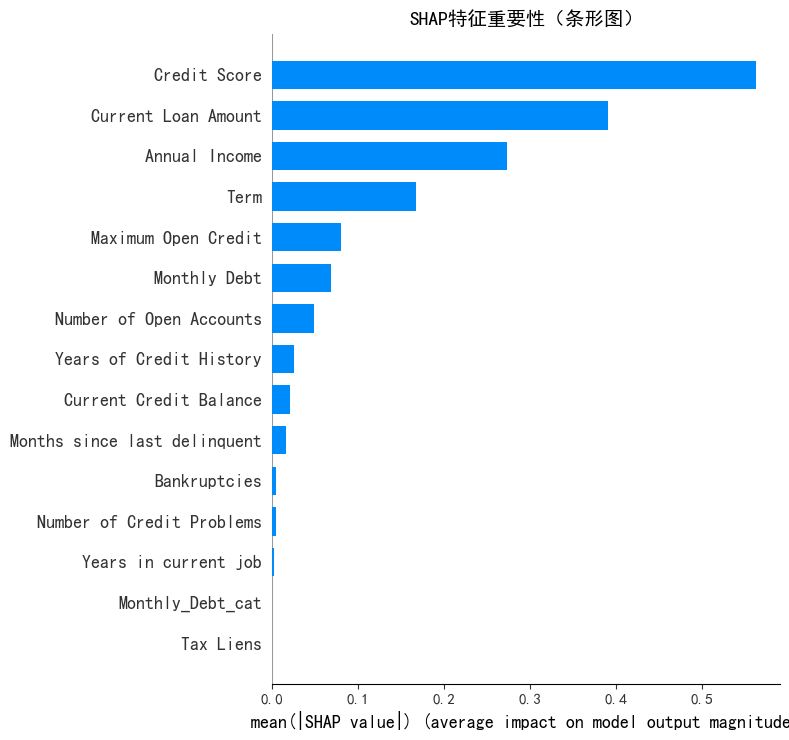

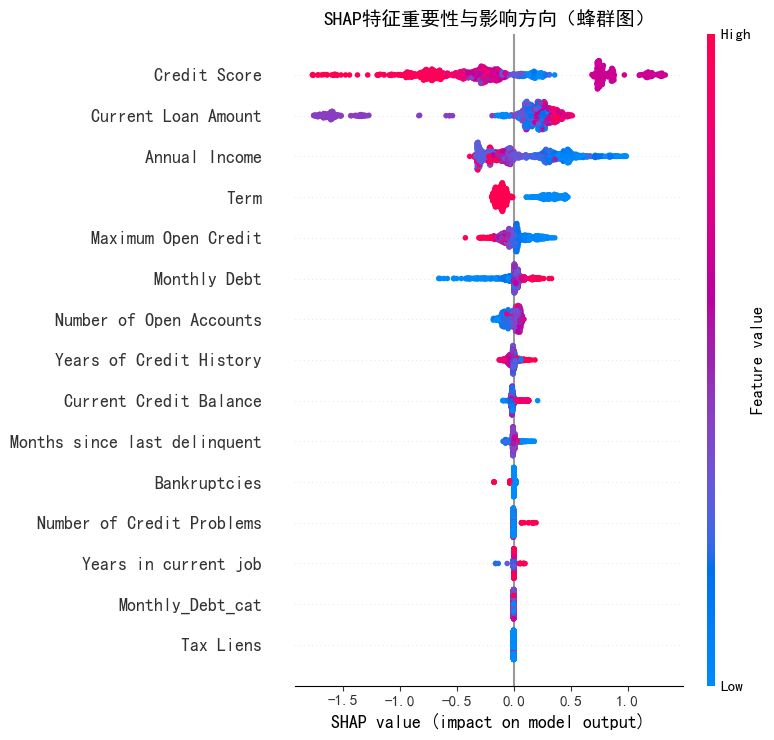

<Figure size 1000x600 with 0 Axes>

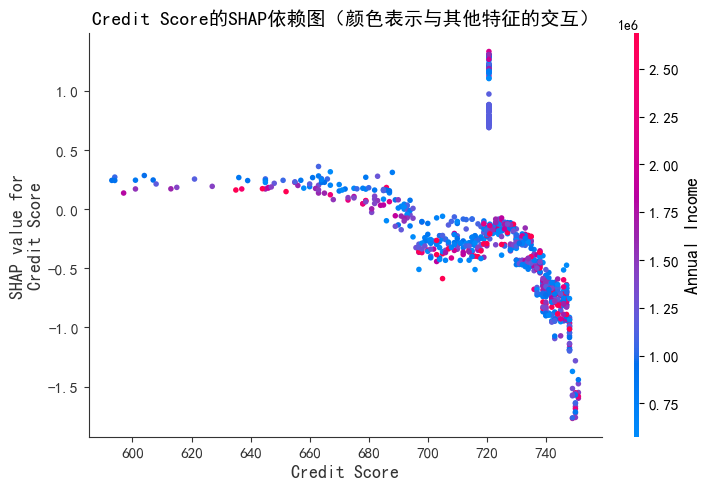

<Figure size 1000x600 with 0 Axes>

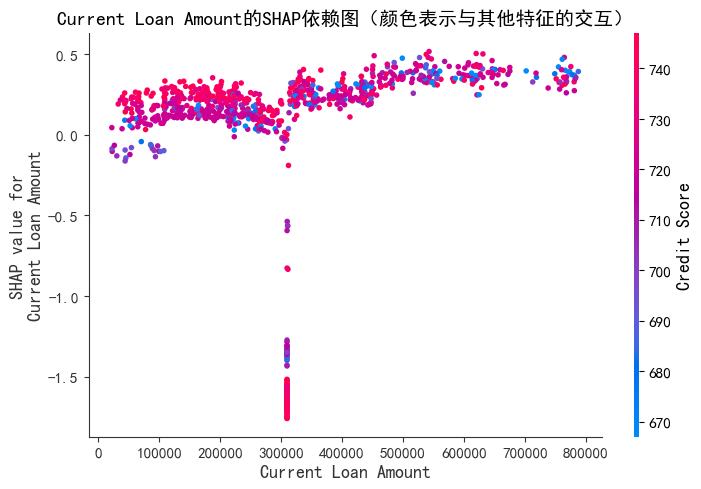

<Figure size 1000x600 with 0 Axes>

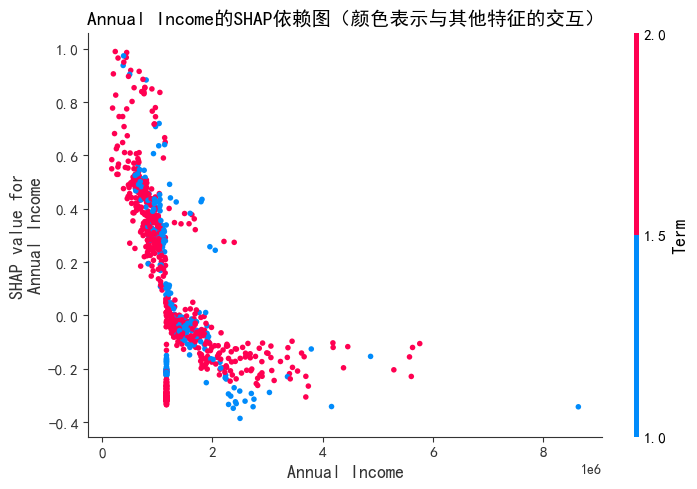

===== 特征SHAP重要性排序 =====
                            特征名称  SHAP重要性（绝对值均值）
13                  Credit Score          0.5620
10           Current Loan Amount          0.3904
0                  Annual Income          0.2735
9                           Term          0.1673
5            Maximum Open Credit          0.0804
12                  Monthly Debt          0.0686
3        Number of Open Accounts          0.0494
4        Years of Credit History          0.0254
11        Current Credit Balance          0.0211
7   Months since last delinquent          0.0171
8                   Bankruptcies          0.0053
6      Number of Credit Problems          0.0050
1           Years in current job          0.0026
2                      Tax Liens          0.0000
14              Monthly_Debt_cat          0.0000


In [ ]:



# ----------------------
# 1. 准备数据和模型
# ----------------------
# X_valid 为验证集特征
feature_names = X_valid.columns.tolist()

# ----------------------
# 2. 初始化SHAP解释器
# ----------------------
# 使用TreeExplainer，支持树模型快速计算SHAP值
explainer = shap.TreeExplainer(model_lgbm)

# 计算验证集的SHAP值（可选择部分样本加速计算，如1000个）
sample_size = min(1000, X_valid.shape[0])
X_sample = X_valid.sample(sample_size, random_state=21)
shap_values = explainer.shap_values(X_sample)

# ----------------------
# 3. 绘制SHAP特征重要性（全局）
# ----------------------
plt.figure(figsize=(10, 8))
# 按SHAP值绝对值的均值排序，取前20个特征（可调整）
shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=feature_names,
    plot_type="bar",  # 条形图展示重要性
    show=False
)
plt.title("SHAP特征重要性（条形图）", fontsize=14)
plt.tight_layout()
plt.show()

# 蜂群图：同时展示特征重要性和影响方向（正/负）
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=feature_names,
    show=False
)
plt.title("SHAP特征重要性与影响方向（蜂群图）", fontsize=14)
plt.tight_layout()
plt.show()

# ----------------------
# 4. 分析top特征的依赖图（单个特征与模型输出的关系）
# ----------------------
# 获取SHAP重要性前3的特征
shap_importance = np.abs(shap_values).mean(0)  # 每个特征的平均SHAP绝对值
top_features = [feature_names[i] for i in shap_importance.argsort()[-3:][::-1]]  # 取top3

# 绘制每个top特征的依赖图（含交互效应）
for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature,  # 特征名称
        shap_values, 
        X_sample, 
        feature_names=feature_names,
        show=False
    )
    plt.title(f"{feature}的SHAP依赖图（颜色表示与其他特征的交互）", fontsize=14)
    plt.tight_layout()
    plt.show()

# ----------------------
# 5. 输出特征重要性数值表
# ----------------------
# 按SHAP重要性排序
shap_importance_df = pd.DataFrame({
    "特征名称": feature_names,
    "SHAP重要性（绝对值均值）": np.abs(shap_values).mean(0)
}).sort_values(by="SHAP重要性（绝对值均值）", ascending=False).round(4)

print("===== 特征SHAP重要性排序 =====")
print(shap_importance_df)